# Oblig 2: FIR filtere

## 5.2

Vi har signalet $x(t) = \cos{\left(2\pi 800 t\right)}$ samplet ved $f_s=1000\ \mathrm{Hz}$:

$$
x[n] = x\left(\frac{n}{f_s}\right) = \cos{\left(\frac{8}{5}\pi n\right)}
$$

Signalet $x[n]$ sendes deretter gjennom et FIR lavpassfilter og gir $y[n]$. Filteret har et passbånd opp til $400\ \mathrm{Hz}$ med passbåndforsterkning på $1$, en $20\ \mathrm{Hz}$ bred overgangsflanke og stopbåndsattenuering på $-60\ \mathrm{dB}$.

En segmentvis tilnærming av $\left|H(j\omega)\right|$ kan for eksempel være:

$$
\left|H(j\omega)\right| = \begin{cases}
1 & \left|\omega\right| \le 2\pi 400\ \mathrm{Hz}\\
10^{-3\frac{\left|\omega\right| - 2\pi 400\ \mathrm{Hz}}{2\pi 20\ \mathrm{Hz}}} & 2\pi 400\ \mathrm{Hz} < \left|\omega\right| < 2\pi 420\ \mathrm{Hz} \\
10^{-3}& \left|\omega\right| \ge 2\pi 420\ \mathrm{Hz}
\end{cases}
$$

### a)

Diskre-tid Fourier-transformen (DTFT) $X(j\omega)$ av $x[n]$ blir:

$$
X(j\omega) = \sum_{n=-\infty}^\infty x[n] e^{-\frac{j\omega}{f_s}n} = \sum_{n=-\infty}^\infty \cos{\left(\frac{8}{5}\pi n\right)} e^{-\frac{j\omega}{f_s}n} = \frac{1}{2}\left(\delta \left(\omega - 2\pi 800\ \mathrm{Hz}\right)+\delta \left(\omega + 2\pi 800\ \mathrm{Hz}\right)\right)
$$

hvor $\delta(\beta)$ er Dirac's deltafunksjon.

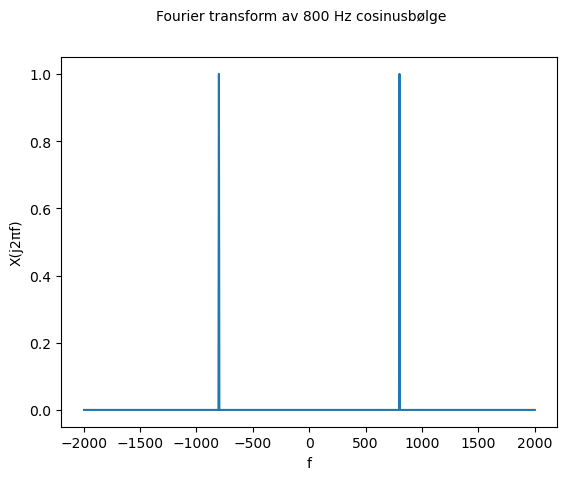

In [23]:
import numpy as np
from matplotlib import pyplot as plt

N = int(1000)
f_s = 1000
f_max = 2*f_s
f_n = 800
f = np.linspace(0, 2*f_max, N) - 2*f_max*(N - 1)/(2*N)
x = np.zeros(N)
x[int((N - 1)/2 + N*f_n/(2*f_max))] += 0.5*f_max/N
x[int((N - 1)/2 - N*f_n/(2*f_max))] += 0.5*f_max/N

fig = plt.figure()
plt.plot(f, x, '-')
fig.suptitle('Fourier transform av 800 Hz cosinusbølge', fontsize=10)
plt.xlabel('f', fontsize=10)
plt.ylabel('X(j2πf)', fontsize=10)
plt.show()

### b)

Ettersom det spektrale innoldet i $X(j\omega)$ befinner seg i stop-båndet til $H(j\omega)$ vil magnituden av utgangssignalet $Y(j\omega)$ bli:

$$
\left|Y(j\omega)\right| = \left|H(j\omega)X(j\omega)\right| = \frac{10^{-3}}{2}\left(\delta \left(\omega - 2\pi 800\ \mathrm{Hz}\right)+\delta \left(\omega + 2\pi 800\ \mathrm{Hz}\right)\right)
$$

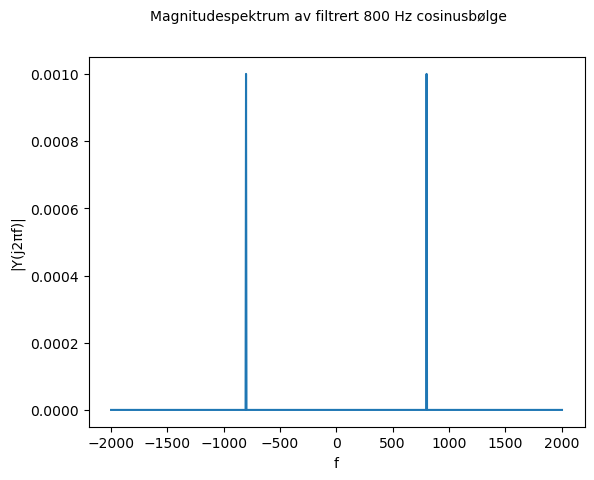

In [28]:
import numpy as np
from matplotlib import pyplot as plt

N = int(1000)
f_s = 1000
f_max = 2*f_s
f_n = 800
f = np.linspace(0, 2*f_max, N) - 2*f_max*(N - 1)/(2*N)
y = np.zeros(N)
y[int((N - 1)/2 + N*f_n/(2*f_max))] += 0.5*f_max/N*1e-3
y[int((N - 1)/2 - N*f_n/(2*f_max))] += 0.5*f_max/N*1e-3

fig = plt.figure()
plt.plot(f, y, '-')
fig.suptitle('Magnitudespektrum av filtrert 800 Hz cosinusbølge', fontsize=10)
plt.xlabel('f', fontsize=10)
plt.ylabel('|Y(j2πf)|', fontsize=10)
plt.show()

### c)

Utgangssignalet vil bli på følgende form, med faseforskyvning $\varphi$:

$$
y[n] = 10^{-3} \cos{\left(\frac{8}{5}\pi n + \varphi\right)}
$$

## 5.3

Tidsforsinkelsen til et FIR-filter kan ikke være større enn $6\ \mathrm{ms}$. Sampleraten på signalet er $f_s = 48\ \mathrm{kHz}$. Vi antar at FIR-filteret har lineær fase. Da vil gruppeforsinkelsen på filteret være lik:

$$
\tau = \frac{N}{2 f_s} \le \tau_\mathrm{max} = 6\ \mathrm{ms}
$$

Antall tapper må da være:

$$
N \le \lfloor 2 f_s \tau_\mathrm{max} \rfloor = 576
$$

## 5.7